In [1]:
%pip install numpy gymnasium scikit-learn torch pandas treeple matplotlib ydf

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.0/9.0 MB 8.4 MB/s eta 0:00:00ta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [ydf]2/3 [ydf]

[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: /opt/homebrew/opt/python@3.10/bin/python3.10 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import sys
sys.path.append("../src")
# from linear_foraging import foraging_playground_linear
import numpy as np
# from foraging_utils import optimal_linear, chance_linear, register_custom_env
import matplotlib.pyplot as plt
import gymnasium as gym
import pickle
from matplotlib.ticker import MultipleLocator
import os
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
import torch.nn as nn
import torch
import pandas as pd
from sklearn.preprocessing import OneHotEncoder
from utils import time_embedding_np, reward_simulate,simulate_data_raw,make_weighted_target,position_encoder
from utils import best_next_state,path_opt,preward_opt,compute_normalized_future_rewards
import ydf
from ydf import GradientBoostedTreesLearner

## Data Generation

In [3]:
# environment setup
# session_duration = 500000
# env_name = 'ForagingPlaygroundLinear-v0'
# register_custom_env(
#     env_name = env_name, 
#     map_name = 'short',
#     base_reward = 10.0,
#     decay_rate = 0.6,
#     reward_period = 10,
#     session_duration = session_duration
# )
# env = gym.make(env_name)

base_reward = 10.0
map_name = "short"
decay_rate = 0.6
reward_period = 10 
session_duration = 500000
rewards_in_period = []

total_steps = session_duration
for period_start in range(0, total_steps, reward_period):
    period_end = min(period_start + reward_period, total_steps)
    steps_in_period = np.arange(period_start, period_end)
    rewards_in_period.extend(base_reward * (decay_rate ** (steps_in_period - period_start)))

pattern = [1,1,1,1,1,1,1,2,3,4,5,5,5,5,5,5,5,4,3,2]
optimal_states = np.array(pattern*(session_duration // len(pattern))).reshape(-1,1)




In [4]:
def get_candidates(state, t):
    if state == 0:
        return [1, 0]
    elif state == 6:
        return [5, 6]
    else:
        # default 3-way split for illustration
        return [state-1, state, state+1]

def enumerate_paths(x0, t_inital = 0, t_prime=20):
    paths = [[x0]]
    for t in range(t_prime):
        new_paths = []
        for path in paths:
            curr = path[-1]
            for nxt in get_candidates(curr, t):
                new_paths.append(path + [nxt])
        paths = new_paths
    
    # Convert to DataFrame: each row is one path, columns t=0..T
    cols = [f"t={t_inital+i}" for i in range(t_prime+1)]
    df = pd.DataFrame(paths, columns=cols)
    return df


## PAFM with Postional Encoding

## PAFM optimal

In [19]:
gamma = 0.5
Ts = [2**i for i in np.arange(7,10)] +[750]+ [1024, 1250, 1500, 2048]

DELTA_t = 5
t_prime = 6
reps = 10
all_seed_results_ydf = {}

for rep in range(reps):
    seed = 516 +rep
    np.random.seed(seed)
    all_seed_results_ydf[seed] = {}
    FUTURE_STATE = []
    for T in Ts:
        n_seq = int(T/DELTA_t)
    # n_seq = T
        print(n_seq)
        state_raw = np.random.choice([int(i) for i in range(7)],size = n_seq)
        time_raw = np.random.choice([int(i) for i in range(T)],size = n_seq)
        opt_paths, opt_times, opt_irewards, opt_prewards = [], [], [], []
        STATES = []
        for i in range(len(time_raw)):
            path, rewards = path_opt(state_raw[i], time_raw[i], DELTA_t)
        # print(state_raw[i],path)
            times = [time_raw[i]+delta_t for delta_t in np.arange(1,DELTA_t+2)] # raw time begin from 1
            opt_paths.append(path)
            opt_irewards.append(rewards)
            opt_times.append(times)
            opt_prewards.append(preward_opt(rewards,gamma = 0.5))
            state_posencode_oh = position_encoder(np.array(path), type="onehot")
            time_emb = time_embedding_np(np.array(times)).reshape(DELTA_t+1,-1)
        # print(time_emb.shape,state_posencode_oh.shape)
            state_pe = np.hstack([state_posencode_oh,time_emb])
            STATES.append(state_pe)
        STATES_arr = np.vstack(STATES)
        REWARDS_arr = np.hstack(np.array(opt_irewards).reshape(-1,1))
        print(STATES_arr.shape,REWARDS_arr.shape)
    # plt.plot(opt_times[0],opt_paths[0])
    # plt.show()
    # plt.plot(opt_times[0],opt_irewards[0])
    # plt.show()
        X_train = STATES_arr
        Y_train = REWARDS_arr

        df_train = pd.DataFrame(X_train)
        feature_labels = [f'feature_{i}' for i in range(X_train.shape[1])]
        df_train.columns = feature_labels
        df_train['target'] = Y_train
        rf = GradientBoostedTreesLearner(label = 'target', task = ydf.Task.REGRESSION, num_trees=1000, random_seed=seed)
        model = rf.train(df_train)
        print(T,'train done')

    
        current_state = np.random.choice([int(i) for i in range(7)],size = 1)
        future_states = [current_state.item()]
    # print(current_state)
        for delta_t in range(100):
            df_all_paths = enumerate_paths(x0=current_state,t_inital = T+delta_t,t_prime=t_prime)
            n_paths = df_all_paths.shape[0]
            irewards_pred = np.zeros((n_paths,  t_prime+1))
            for i in range(t_prime+1):
                cand_pe = position_encoder(df_all_paths.iloc[:,i], type="onehot")
                curr_time = T+1+delta_t+i
                time_emb = time_embedding_np(np.ones(cand_pe.shape[0])*curr_time, tdim=50)
                features = np.hstack([cand_pe,time_emb])
                features_pd = pd.DataFrame(features, columns = feature_labels)
                irewards_pred[:,i] = model.predict(features_pd)
            reward_cols = [f"t={T+delta_t+t}" for t in range(t_prime+1)]
            df_ireward = pd.DataFrame(irewards_pred, columns=reward_cols)
        # Extract rewards from second column onward (t=1 to t=T)
            rewards_matrix = df_ireward.iloc[:, 1:].values  # shape (n_paths, T)
            discounts = gamma ** np.arange(1, t_prime+1)

        # Compute discounted total reward per path
            discounted_returns = rewards_matrix * discounts  
            total_discounted = discounted_returns.sum(axis=1)
        # print(total_discounted)
            bext_idx = np.argmax(total_discounted)
            next_state = int(df_all_paths.iloc[bext_idx,1])
        # print(df_all_paths.iloc[bext_idx,:])
            future_states.append(next_state)
            current_state = next_state
    
    # print(T,future_states,len(future_states))
        FUTURE_STATE.append(future_states)

        irewards = [reward_simulate(future_states[i],T+i,rewards_in_period) for i in np.arange(1,len(future_states))]
        preward = compute_normalized_future_rewards(irewards,100,0.5)
        path, ireward_opt = path_opt(future_states[0], T, 100)
        preward_opt_test = compute_normalized_future_rewards(ireward_opt[1:],100,0.5)
        pregret = (np.sum(preward_opt_test).item()-np.sum(preward).item())/100
        print(pregret)
        plt.plot(np.arange(T+1,T+101),future_states[1:])
        plt.plot(np.arange(T,T+101),path)
        plt.show()
    all_seed_results_ydf[seed][t_prime] = FUTURE_STATE.copy()




25


TypeError: 'numpy.ndarray' object is not callable

Processing seed: 515
Processing seed: 516
Processing seed: 517
Processing seed: 518
Processing seed: 519
Processing seed: 520
Processing seed: 521
Processing seed: 522
Processing seed: 523
Processing seed: 524
Pregrets shape: (10, 8)
Mean pregrets: [1.03388546 0.42962754 0.39109665 0.02565369 0.02385192 0.02997963
 0.00462996 0.02883546]


/var/folders/7s/xvdffqdj1bb5lm_5b2_s8lxw0000gn/T/ipykernel_41102/3209293595.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name)


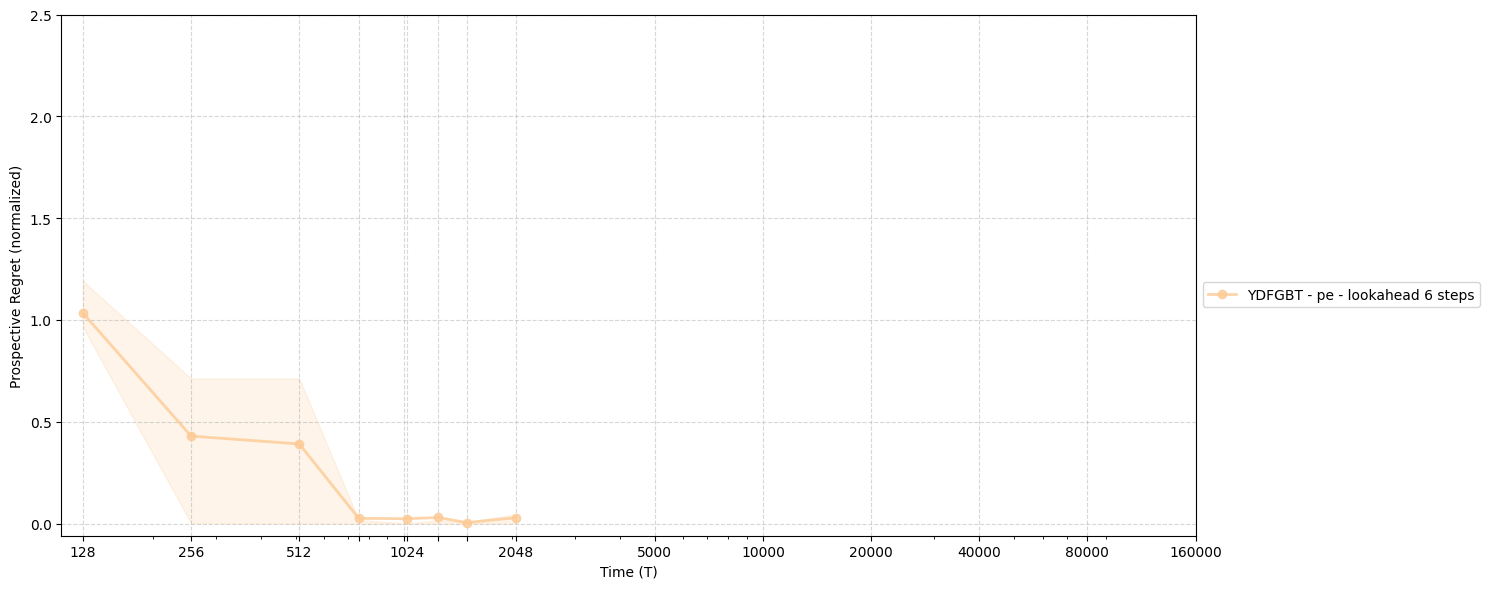

In [15]:
from matplotlib import cm

def get_close_colors(cmap_name, start=0.5, delta=0.15, n=2):
    cmap = cm.get_cmap(cmap_name)
    cmap_color = [cmap(start + i*delta) for i in range(n)]
    return cmap_color[:n]

pafm_pe_orf, pafm_oh_orf, pafm_pe, pafm_oh = get_close_colors("PuRd", start=0.1, delta=0.25, n=4)
skgbt_pe, skgbt_oh = get_close_colors("GnBu", start=0.1, delta=0.2, n=2) 
ydfgbt_pe, ydfgbt_oh = get_close_colors("YlOrBr", start=0.9, delta=0.2, n=2) 
ydfrf_pe, ydfrf_oh = get_close_colors("OrRd", start=0.1, delta=0.2, n=2) 

colors = {
    "YDFRF_pe": ydfrf_pe,
    "YDFRF_oh": ydfrf_oh
}

t_prime = 6
Ts = [2**i for i in np.arange(7,10)]+[750]+[1024,1250,1500,2048]
seeds = [515, 516, 517, 518, 519, 520, 521, 522, 523, 524]

all_pregrets = []
all_prewards = []

for seed in seeds:
    print(f"Processing seed: {seed}")
    
    # Get the FUTURE_STATE data for this seed
    future_states_list = all_seed_results_ydf[seed][t_prime]
    
    prewards = []
    pregrets = []
    
    for k, T in enumerate(Ts):
        if k < len(future_states_list):
            # Get the future states for this T value
            states_trajectory = future_states_list[k]
            
            irewards = [reward_simulate(states_trajectory[i], T+i, rewards_in_period) 
                       for i in range(1, len(states_trajectory))]
            
            preward = compute_normalized_future_rewards(irewards, 100, 0.5)
            
            path, ireward_opt = path_opt(states_trajectory[0], T, 100)
            preward_opt = compute_normalized_future_rewards(ireward_opt[1:], 100, 0.5)
            
            pregret = (np.sum(preward_opt).item() - np.sum(preward).item()) / 100
            
            prewards.append(np.sum(preward).item())
            pregrets.append(pregret)
        else:
            print(f"Warning: No data for T={T} in seed {seed}")
            prewards.append(np.nan)
            pregrets.append(np.nan)
    
    all_prewards.append(prewards)
    all_pregrets.append(pregrets)
PREWARDS_arr = np.array(all_prewards)
PREGRETS_arr = np.array(all_pregrets)

# Calculate mean and percentiles across seeds
PREGRETS_mean = np.nanmean(PREGRETS_arr, axis=0)
PREGRETS_25th = np.nanpercentile(PREGRETS_arr, 25, axis=0)
PREGRETS_75th = np.nanpercentile(PREGRETS_arr, 75, axis=0)

print(f"Pregrets shape: {PREGRETS_arr.shape}")
print(f"Mean pregrets: {PREGRETS_mean}")

plt.figure(figsize=(15, 6))

plt.plot(Ts, PREGRETS_mean, alpha=0.8, marker='o', color=colors["YDFRF_oh"], 
         label='YDFGBT - pe - lookahead 6 steps', linewidth=2, markersize=6)

plt.fill_between(Ts, PREGRETS_25th, PREGRETS_75th, 
                 alpha=0.2, color=colors["YDFRF_oh"])

Ts_PAFM = [2**i for i in np.arange(7,10)]+[750]+[1024,1250,1500,2048]
Ts_PVFM = [1000,5000,10000,20000,40000,80000,160000]

plt.xlabel("Time (T)")
plt.ylabel("Prospective Regret (normalized)")
plt.xscale('log')
xticks = Ts_PAFM + Ts_PVFM
xticklabels = [str(v) if v in [128,256,512,1024,2048,5000,10000,20000,40000,80000,160000] else ""
               for i, v in enumerate(xticks)]
plt.xticks(xticks, labels=xticklabels)
plt.yticks([0,0.5,1,1.5,2,2.5])

plt.legend(loc="upper left", bbox_to_anchor=(1, 0.5))
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()
